# Label data

In [1]:
import os
import json

# Stage 1

In [ ]:
def collect_images_with_labels(dataset_root, exts=(".png", ".jpg", ".jpeg")):
    data = []
    for label_name in ["efs", "fr", "fs", "real"]:
        folder_path = os.path.join(dataset_root, label_name)
        if not os.path.exists(folder_path):
            print(f"Warning: {folder_path} not found, skipping...")
            continue

        for dirpath, _, filenames in os.walk(folder_path):
            for filename in filenames:
                if filename.lower().endswith(exts):
                    img_path = os.path.join(dirpath, filename)
                    data.append({"image": img_path, "label": label_name})
    return data

In [17]:
dataset_root = "D:\\Github\\Deepfake_Detection\\data\\train"
  # change this to your dataset root
data = collect_images_with_labels(dataset_root)

output_json = "image_labels.json"
with open(output_json, "w", encoding="utf-8") as f:
    json.dump(data, f, ensure_ascii=False, indent=2)

print(f"Found {len(data)} images and saved labels to {output_json}")

Found 1504800 images and saved labels to image_labels.json


# Stage 2

In [ ]:
import os
import json
import random

# Paths
train_dir = "D:\\Github\\Deepfake_Detection\\data\\train"
output_file = "image_labels_stage2.json"


def valid_img(fname):
    return fname.lower().endswith((".png", ".jpg", ".jpeg")) and "dup" not in fname.lower()

# Collect real images (keep dup intact)
real_dir = os.path.join(train_dir, "real")
real_images = [os.path.join("real", f) for f in os.listdir(real_dir)
               if f.lower().endswith((".png", ".jpg", ".jpeg"))]

# Collect fake images per main folder and subfolder
fake_dirs = ["efs", "fr", "fs"]
fake_images_by_subfolder = {}

for d in fake_dirs:
    fake_images_by_subfolder[d] = {}
    dpath = os.path.join(train_dir, d)
    for sub in os.listdir(dpath):
        subpath = os.path.join(dpath, sub)
        if os.path.isdir(subpath):
            imgs = [os.path.join(d, sub, f) for f in os.listdir(subpath) if valid_img(f)]
            if imgs:  # Only add if there are valid images
                fake_images_by_subfolder[d][sub] = imgs

# Step 1: Balance within each method (efs, fr, fs)
method_balanced_images = {}

for method in fake_dirs:
    subfolders = fake_images_by_subfolder[method]
    
    if not subfolders:
        method_balanced_images[method] = []
        continue
    
    # Find minimum count within this method's subfolders
    subfolder_counts = {sub: len(imgs) for sub, imgs in subfolders.items()}
    min_count_in_method = min(subfolder_counts.values())
    
    print(f"\n{method.upper()} Method:")
    print(f"Subfolder counts: {subfolder_counts}")
    print(f"Minimum count in {method}: {min_count_in_method}")
    
    # Sample each subfolder to the minimum count within this method
    balanced_subfolders = {}
    for subfolder, imgs in subfolders.items():
        balanced_subfolders[subfolder] = random.sample(imgs, min_count_in_method)
    
    # Combine all balanced subfolders for this method
    method_images = []
    for subfolder_imgs in balanced_subfolders.values():
        method_images.extend(subfolder_imgs)
    
    method_balanced_images[method] = method_images
    print(f"Total {method} after internal balancing: {len(method_images)}")

# Step 2: Balance between methods (efs, fr, fs)
method_totals = [len(method_balanced_images[method]) for method in fake_dirs]
min_method_total = min(method_totals)

print(f"\nMethod totals after internal balancing: {dict(zip(fake_dirs, method_totals))}")
print(f"Minimum method total: {min_method_total}")

# Sample each method down to the minimum method total
final_method_images = {}
for method in fake_dirs:
    if len(method_balanced_images[method]) > min_method_total:
        final_method_images[method] = random.sample(method_balanced_images[method], min_method_total)
    else:
        final_method_images[method] = method_balanced_images[method]
    print(f"Final {method} count: {len(final_method_images[method])}")

# Step 3: Balance Real vs Fake
total_fake = sum(len(final_method_images[method]) for method in fake_dirs)
total_real = len(real_images)

print(f"\nBefore Real vs Fake balancing:")
print(f"Total Real: {total_real}")
print(f"Total Fake: {total_fake}")

# Balance real vs fake
if total_real > total_fake:
    # Too many real images, sample down
    final_real_images = random.sample(real_images, total_fake)
    final_fake_images = []
    for method in fake_dirs:
        final_fake_images.extend(final_method_images[method])
elif total_fake > total_real:
    # Too many fake images, need to reduce fake proportionally
    reduction_ratio = total_real / total_fake
    final_fake_images = []
    
    for method in fake_dirs:
        method_target = int(len(final_method_images[method]) * reduction_ratio)
        if method_target > 0:
            sampled_method = random.sample(final_method_images[method], method_target)
            final_fake_images.extend(sampled_method)
    
    final_real_images = real_images
else:
    # Already balanced
    final_real_images = real_images
    final_fake_images = []
    for method in fake_dirs:
        final_fake_images.extend(final_method_images[method])

# Build dataset
dataset = []
for img in final_real_images:
    dataset.append({"image": img, "label": "real"})
for img in final_fake_images:
    dataset.append({"image": img, "label": "fake"})

# Shuffle the dataset
random.shuffle(dataset)

# Save
with open(output_file, "w") as f:
    json.dump(dataset, f, indent=2)

print(f"\nFinal balanced dataset:")
print(f"Real: {len(final_real_images)}")
print(f"Fake: {len(final_fake_images)}")
print(f"Total: {len(dataset)}")
print(f"Saved {len(dataset)} entries to {output_file}")


EFS Method:
Subfolder counts: {'ddim': 21589, 'DiT': 21589, 'pixart': 21589, 'RDDM': 21589, 'sd2.1': 21589, 'SiT': 21589, 'StyleGAN2': 21589, 'StyleGAN3': 21589, 'StyleGANXL': 21589, 'VQGAN': 21589}
Minimum count in efs: 21589
Total efs after internal balancing: 215890

FR Method:
Subfolder counts: {'danet': 22646, 'facevid2vid': 22815, 'fomm': 22811, 'hyperreenact': 18783, 'lia': 22811, 'mcnet': 22613, 'MRAA': 22811, 'one_shot_free': 22959, 'pirender': 22914, 'sadtalker': 22797, 'tpsm': 22964, 'wav2lip': 22682}
Minimum count in fr: 18783
Total fr after internal balancing: 225396

FS Method:
Subfolder counts: {'blendface': 22513, 'e4s': 22779, 'facedancer': 22747, 'faceswap': 22852, 'fsgan': 21815, 'inswap': 27988, 'mobileswap': 22824, 'simswap': 31350, 'uniface': 11794}
Minimum count in fs: 11794
Total fs after internal balancing: 106146

Method totals after internal balancing: {'efs': 215890, 'fr': 225396, 'fs': 106146}
Minimum method total: 106146
Final efs count: 106146
Final fr c

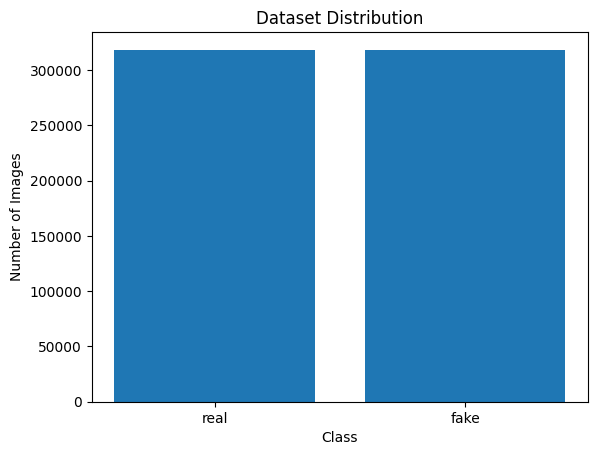

In [12]:
import json
import matplotlib.pyplot as plt
from collections import Counter
# Load the json file
with open("image_labels_stage2.json", "r") as f:
    dataset = json.load(f)

# Count labels
label_counts = Counter([item["label"] for item in dataset])

# Plot bar chart (real vs fake)
plt.bar(label_counts.keys(), label_counts.values())
plt.title("Dataset Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

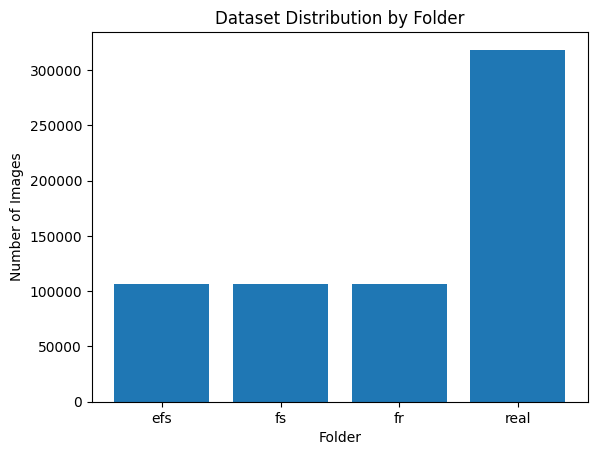

In [13]:
from collections import defaultdict

# Count per subfolder
sub_counts = defaultdict(int)
for item in dataset:
    if item["label"] == "fake":
        subfolder = item["image"].split("\\")[0]  # for Windows-style paths
        sub_counts[subfolder] += 1

# Add real count
sub_counts["real"] = label_counts["real"]

# Plot
plt.bar(sub_counts.keys(), sub_counts.values())
plt.title("Dataset Distribution by Folder")
plt.xlabel("Folder")
plt.ylabel("Number of Images")
plt.show()

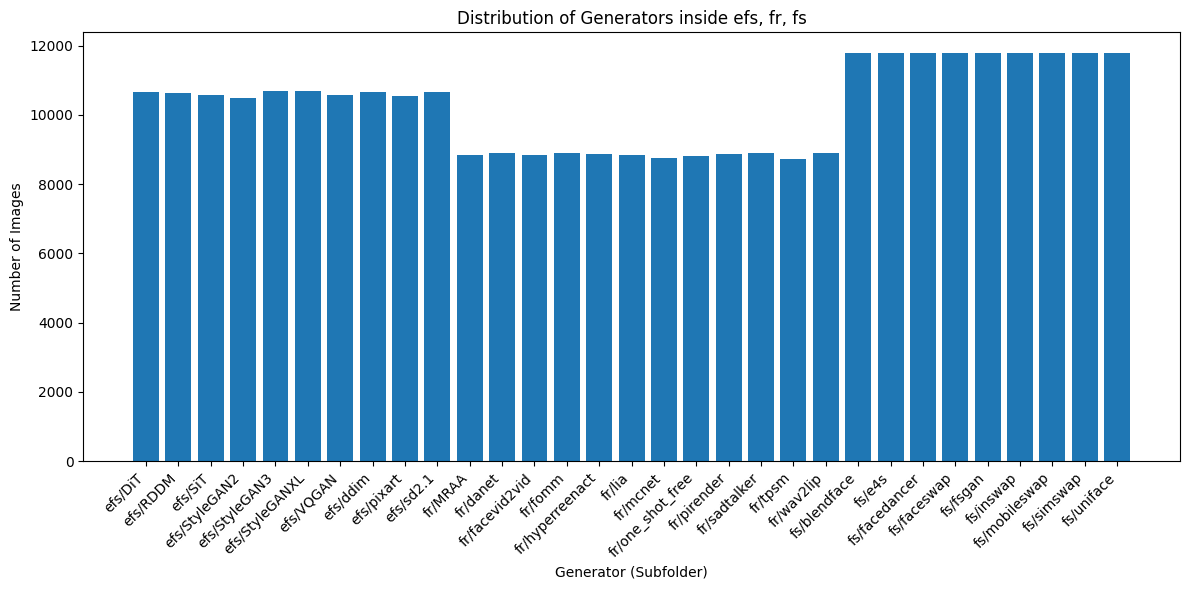

: 

In [ ]:
from collections import defaultdict
import matplotlib.pyplot as plt

gen_counts = defaultdict(int)

for item in dataset:
    if item["label"] == "fake":
        parts = item["image"].split("\\")  # Windows-style path
        if len(parts) >= 3:
            folder, generator = parts[0], parts[1]
            gen_counts[f"{folder}/{generator}"] += 1

# Sort by generator names
sorted_gen_counts = dict(sorted(gen_counts.items()))

# Plot
plt.figure(figsize=(12,6))
plt.bar(sorted_gen_counts.keys(), sorted_gen_counts.values())
plt.title("Distribution of Generators inside efs, fr, fs")
plt.xlabel("Generator (Subfolder)")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Test set

In [2]:
import os
import json
import random

# Paths
train_dir = "D:\\Github\\Deepfake_Detection\\data\\test"
output_file = "image_labels_test.json"


def valid_img(fname):
    return fname.lower().endswith((".png", ".jpg", ".jpeg")) and "dup" not in fname.lower()

# Collect real images (keep dup intact)
real_dir = os.path.join(train_dir, "real")
real_images = []

for root, _, files in os.walk(real_dir):
    for f in files:
        if f.lower().endswith((".png", ".jpg", ".jpeg")):
            # Relative path from train_dir
            rel_path = os.path.relpath(os.path.join(root, f), train_dir)
            real_images.append(rel_path)

# Collect fake images per main folder and subfolder
fake_dirs = ["efs", "fr", "fs", "fe"]
fake_images_by_subfolder = {}

for d in fake_dirs:
    fake_images_by_subfolder[d] = {}
    dpath = os.path.join(train_dir, d)
    for sub in os.listdir(dpath):
        subpath = os.path.join(dpath, sub)
        if os.path.isdir(subpath):
            imgs = [os.path.join(d, sub, f) for f in os.listdir(subpath) if valid_img(f)]
            if imgs:  # Only add if there are valid images
                fake_images_by_subfolder[d][sub] = imgs

# Step 1: Balance within each method (efs, fr, fs, fe)
method_balanced_images = {}

for method in fake_dirs:
    subfolders = fake_images_by_subfolder[method]
    
    if not subfolders:
        method_balanced_images[method] = []
        continue
    
    # Find minimum count within this method's subfolders
    subfolder_counts = {sub: len(imgs) for sub, imgs in subfolders.items()}
    min_count_in_method = min(subfolder_counts.values())
    
    print(f"\n{method.upper()} Method:")
    print(f"Subfolder counts: {subfolder_counts}")
    print(f"Minimum count in {method}: {min_count_in_method}")
    
    # Sample each subfolder to the minimum count within this method
    balanced_subfolders = {}
    for subfolder, imgs in subfolders.items():
        balanced_subfolders[subfolder] = random.sample(imgs, min_count_in_method)
    
    # Combine all balanced subfolders for this method
    method_images = []
    for subfolder_imgs in balanced_subfolders.values():
        method_images.extend(subfolder_imgs)
    
    method_balanced_images[method] = method_images
    print(f"Total {method} after internal balancing: {len(method_images)}")

# Step 2: Balance between methods (efs, fr, fs)
method_totals = [len(method_balanced_images[method]) for method in fake_dirs]
min_method_total = min(method_totals)

print(f"\nMethod totals after internal balancing: {dict(zip(fake_dirs, method_totals))}")
print(f"Minimum method total: {min_method_total}")

# Sample each method down to the minimum method total
final_method_images = {}
for method in fake_dirs:
    if len(method_balanced_images[method]) > min_method_total:
        final_method_images[method] = random.sample(method_balanced_images[method], min_method_total)
    else:
        final_method_images[method] = method_balanced_images[method]
    print(f"Final {method} count: {len(final_method_images[method])}")

# Step 3: Balance Real vs Fake
total_fake = sum(len(final_method_images[method]) for method in fake_dirs)
total_real = len(real_images)

print(f"\nBefore Real vs Fake balancing:")
print(f"Total Real: {total_real}")
print(f"Total Fake: {total_fake}")

# Balance real vs fake
if total_real > total_fake:
    # Too many real images, sample down
    final_real_images = random.sample(real_images, total_fake)
    final_fake_images = []
    for method in fake_dirs:
        final_fake_images.extend(final_method_images[method])
elif total_fake > total_real:
    # Too many fake images, need to reduce fake proportionally
    reduction_ratio = total_real / total_fake
    final_fake_images = []
    
    for method in fake_dirs:
        method_target = int(len(final_method_images[method]) * reduction_ratio)
        if method_target > 0:
            sampled_method = random.sample(final_method_images[method], method_target)
            final_fake_images.extend(sampled_method)
    
    final_real_images = real_images
else:
    # Already balanced
    final_real_images = real_images
    final_fake_images = []
    for method in fake_dirs:
        final_fake_images.extend(final_method_images[method])

# Build dataset
dataset = []
for img in final_real_images:
    dataset.append({"image": img, "label": "real"})
for img in final_fake_images:
    dataset.append({"image": img, "label": "fake"})

# Shuffle the dataset
random.shuffle(dataset)

# Save
with open(output_file, "w") as f:
    json.dump(dataset, f, indent=2)

print(f"\nFinal balanced dataset:")
print(f"Real: {len(final_real_images)}")
print(f"Fake: {len(final_fake_images)}")
print(f"Total: {len(dataset)}")
print(f"Saved {len(dataset)} entries to {output_file}")


EFS Method:
Subfolder counts: {'ddim': 31885, 'DiT': 31885, 'MidJourney': 630, 'pixart': 31885, 'RDDM': 17738, 'sd2.1': 53474, 'SiT': 31885, 'StyleGAN2': 31885, 'StyleGAN3': 31885, 'StyleGANXL': 31885, 'VQGAN': 31885, 'whichfaceisreal': 1001}
Minimum count in efs: 630
Total efs after internal balancing: 7560

FR Method:
Subfolder counts: {'danet': 23696, 'facevid2vid': 24358, 'fomm': 24733, 'heygen-014': 1605, 'hyperreenact': 24983, 'lia': 24254, 'mcnet': 23602, 'MRAA': 24729, 'one_shot_free': 25096, 'pirender': 24664, 'sadtalker': 25402, 'tpsm': 25030, 'wav2lip': 25193}
Minimum count in fr: 1605
Total fr after internal balancing: 20865

FS Method:
Subfolder counts: {'blendface': 24790, 'deepfacelab': 3122, 'e4s': 12861, 'facedancer': 24710, 'faceswap': 24634, 'fsgan': 24056, 'inswap': 17195, 'mobileswap': 47522, 'simswap': 24790, 'uniface': 24346}
Minimum count in fs: 3122
Total fs after internal balancing: 31220

FE Method:
Subfolder counts: {'CollabDiff': 1000, 'e4e': 60123, 'starg

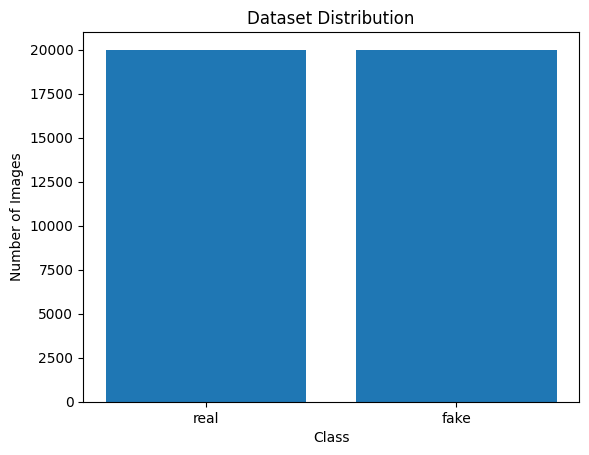

In [9]:
import json
import matplotlib.pyplot as plt
from collections import Counter
# Load the json file
with open("image_labels_test.json", "r") as f:
    dataset = json.load(f)

# Count labels
label_counts = Counter([item["label"] for item in dataset])

# Plot bar chart (real vs fake)
plt.bar(label_counts.keys(), label_counts.values())
plt.title("Dataset Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

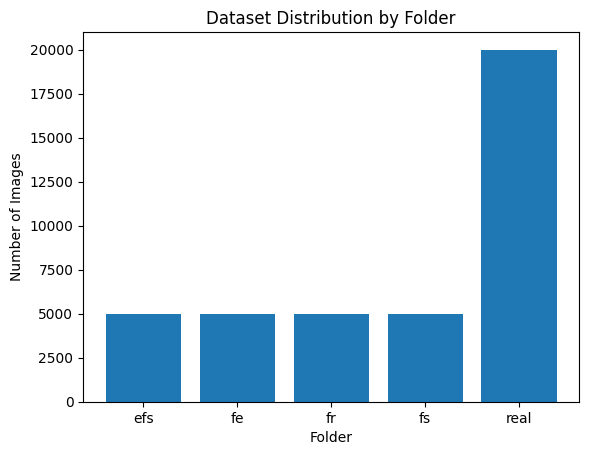

In [10]:
from collections import defaultdict

# Count per subfolder
sub_counts = defaultdict(int)
for item in dataset:
    if item["label"] == "fake":
        subfolder = item["image"].split("\\")[0]  # for Windows-style paths
        sub_counts[subfolder] += 1

# Add real count
sub_counts["real"] = label_counts["real"]

# Plot
plt.bar(sub_counts.keys(), sub_counts.values())
plt.title("Dataset Distribution by Folder")
plt.xlabel("Folder")
plt.ylabel("Number of Images")
plt.show()

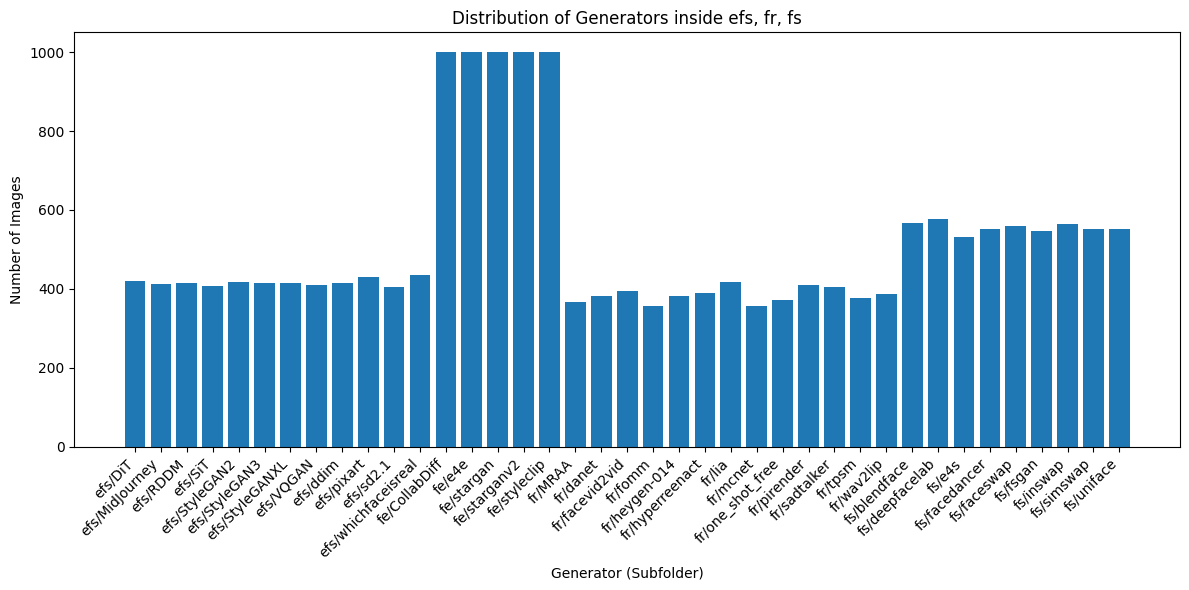

In [11]:
from collections import defaultdict
import matplotlib.pyplot as plt

gen_counts = defaultdict(int)

for item in dataset:
    if item["label"] == "fake":
        parts = item["image"].split("\\")  # Windows-style path
        if len(parts) >= 3:
            folder, generator = parts[0], parts[1]
            gen_counts[f"{folder}/{generator}"] += 1

# Sort by generator names
sorted_gen_counts = dict(sorted(gen_counts.items()))

# Plot
plt.figure(figsize=(12,6))
plt.bar(sorted_gen_counts.keys(), sorted_gen_counts.values())
plt.title("Distribution of Generators inside efs, fr, fs")
plt.xlabel("Generator (Subfolder)")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Balance all generator with real (200 each generators and 200 real)

In [3]:
# Paths
train_dir = "D:\\Github\\Deepfake_Detection\\data\\test"
output_file = "image_labels_test.json"

def valid_img(fname):
    return fname.lower().endswith((".png", ".jpg", ".jpeg")) and "dup" not in fname.lower()

# Collect real images (recursive)
real_dir = os.path.join(train_dir, "real")
real_images = []
for root, _, files in os.walk(real_dir):
    for f in files:
        if f.lower().endswith((".png", ".jpg", ".jpeg")):
            rel_path = os.path.relpath(os.path.join(root, f), train_dir)
            real_images.append(rel_path)

# Collect fake images by method → generator
fake_dirs = ["efs", "fr", "fs", "fe"]
fake_images_by_subfolder = {}

for d in fake_dirs:
    fake_images_by_subfolder[d] = {}
    dpath = os.path.join(train_dir, d)
    for sub in os.listdir(dpath):
        subpath = os.path.join(dpath, sub)
        if os.path.isdir(subpath):
            imgs = [os.path.join(d, sub, f) for f in os.listdir(subpath) if valid_img(f)]
            if imgs:
                fake_images_by_subfolder[d][sub] = imgs

# Step 1: Sample 200 per generator
final_fake_images = []
for method, subfolders in fake_images_by_subfolder.items():
    for gen_name, imgs in subfolders.items():
        if len(imgs) >= 200:
            sampled = random.sample(imgs, 200)
        else:
            sampled = imgs  # not enough images, take all
        print(f"{method}/{gen_name}: picked {len(sampled)} images")
        final_fake_images.extend([{"image": img, "label": "fake"} for img in sampled])

# Step 2: Sample 200 real images
if len(real_images) >= 200:
    final_real_images = random.sample(real_images, 200)
else:
    final_real_images = real_images
print(f"real: picked {len(final_real_images)} images")

# Build dataset
dataset = [{"image": img, "label": "real"} for img in final_real_images] + final_fake_images

# Shuffle
random.shuffle(dataset)

# Save
with open(output_file, "w") as f:
    json.dump(dataset, f, indent=2)

print(f"\nFinal dataset:")
print(f"Real: {len(final_real_images)}")
print(f"Fake: {len(final_fake_images)}")
print(f"Total: {len(dataset)}")

efs/ddim: picked 200 images
efs/DiT: picked 200 images
efs/MidJourney: picked 200 images
efs/pixart: picked 200 images
efs/RDDM: picked 200 images
efs/sd2.1: picked 200 images
efs/SiT: picked 200 images
efs/StyleGAN2: picked 200 images
efs/StyleGAN3: picked 200 images
efs/StyleGANXL: picked 200 images
efs/VQGAN: picked 200 images
efs/whichfaceisreal: picked 200 images
fr/danet: picked 200 images
fr/facevid2vid: picked 200 images
fr/fomm: picked 200 images
fr/heygen-014: picked 200 images
fr/hyperreenact: picked 200 images
fr/lia: picked 200 images
fr/mcnet: picked 200 images
fr/MRAA: picked 200 images
fr/one_shot_free: picked 200 images
fr/pirender: picked 200 images
fr/sadtalker: picked 200 images
fr/tpsm: picked 200 images
fr/wav2lip: picked 200 images
fs/blendface: picked 200 images
fs/deepfacelab: picked 200 images
fs/e4s: picked 200 images
fs/facedancer: picked 200 images
fs/faceswap: picked 200 images
fs/fsgan: picked 200 images
fs/inswap: picked 200 images
fs/mobileswap: picked 

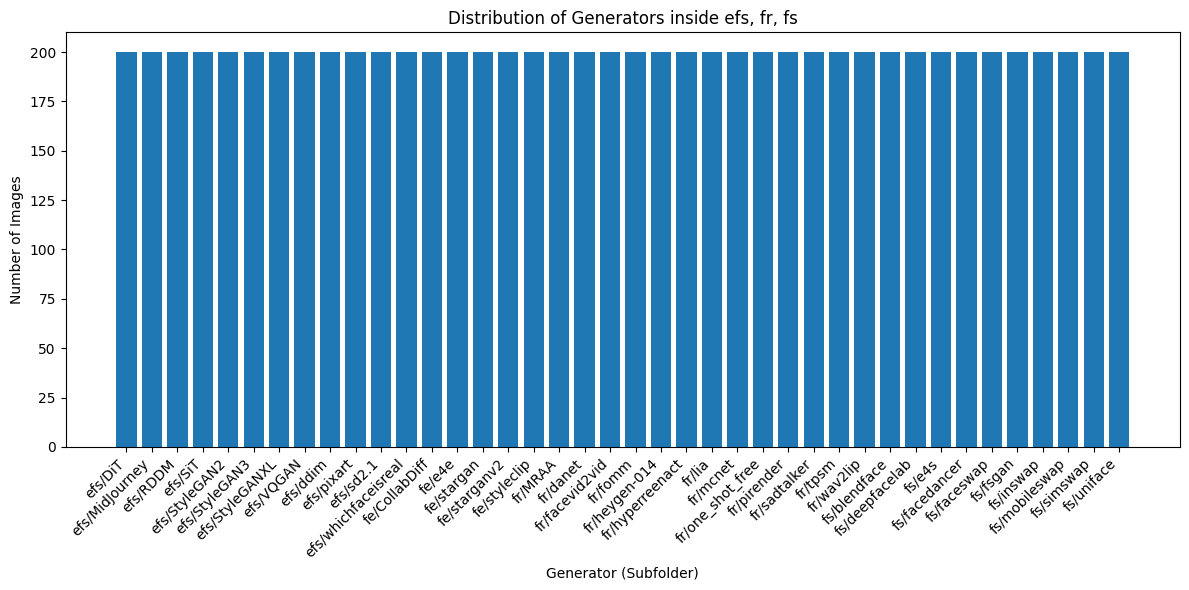

In [4]:
from collections import defaultdict
import matplotlib.pyplot as plt

gen_counts = defaultdict(int)

for item in dataset:
    if item["label"] == "fake":
        parts = item["image"].split("\\")  # Windows-style path
        if len(parts) >= 3:
            folder, generator = parts[0], parts[1]
            gen_counts[f"{folder}/{generator}"] += 1

# Sort by generator names
sorted_gen_counts = dict(sorted(gen_counts.items()))

# Plot
plt.figure(figsize=(12,6))
plt.bar(sorted_gen_counts.keys(), sorted_gen_counts.values())
plt.title("Distribution of Generators inside efs, fr, fs")
plt.xlabel("Generator (Subfolder)")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [4]:
import json
import os
import random

# Paths
json_file = "image_labels_test.json"  # your existing json file
mobileswap_folder = "D:\\Github\\Deepfake_Detection\\data\\test\\fs\\mobileswap"  # folder with new images
output_file = "image_labels_test.json"

# Load existing json
with open(json_file, "r") as f:
    data = json.load(f)

# Ensure it's a list
if not isinstance(data, list):
    raise ValueError("JSON root must be a list of records")

# Get mobileswap images
all_images = [os.path.join(mobileswap_folder, img) for img in os.listdir(mobileswap_folder)]
random.shuffle(all_images)  # shuffle order
selected_images = all_images[:200]  # pick 200 random

# Append new records
for img in selected_images:
    data.append({"image": img, "label": "fake"})

# Save updated json
with open(output_file, "w") as f:
    json.dump(data, f, indent=2)

print(f"Appended {len(selected_images)} random fake images from {mobileswap_folder} to {output_file}")


Appended 200 random fake images from D:\Github\Deepfake_Detection\data\test\fs\mobileswap to image_labels_test.json
